In [5]:
!pip install -q yfinance pandas lxml

In [6]:
import pandas as pd
import yfinance as yf
from datetime import date

START = '2010-01-01'
END   = date.today().isoformat()
print(f'Pulling closing prices from {START} to {END}')

Pulling closing prices from 2010-01-01 to 2026-04-30


In [9]:
import requests
from io import StringIO

url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
# Wikipedia 403s requests without a real User-Agent — pretend to be a browser
headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}
html = requests.get(url, headers=headers, timeout=20).text
tables = pd.read_html(StringIO(html))
constituents = tables[0]
constituents.columns = [c.lower().replace(' ', '_') for c in constituents.columns]
# Yahoo expects '.' replaced with '-' for tickers like BRK.B → BRK-B
tickers = [t.replace('.', '-') for t in constituents['symbol'].tolist()]
print(f'Loaded {len(tickers)} S&P 500 tickers from Wikipedia')
constituents.head()

Loaded 503 S&P 500 tickers from Wikipedia


,symbol,security,gics_sector,gics_sub-industry,headquarters_location,date_added,cik,founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [10]:
idx = yf.download('^GSPC', start=START, end=END, auto_adjust=False, progress=False)
idx = idx[['Close', 'Adj Close', 'Volume']].droplevel(1, axis=1) if isinstance(idx.columns, pd.MultiIndex) else idx[['Close', 'Adj Close', 'Volume']]
idx.columns = ['close', 'adj_close', 'volume']
idx.index.name = 'date'
idx.to_csv('sp500_index.csv')
print(f'sp500_index.csv: {len(idx):,} rows ({idx.index.min().date()} → {idx.index.max().date()})')
idx.head()

sp500_index.csv: 4,105 rows (2010-01-04 → 2026-04-29)


,close,adj_close,volume
date,,,
2010-01-04,1132.989990,1132.989990,3991400000
2010-01-05,1136.520020,1136.520020,2491020000
2010-01-06,1137.140015,1137.140015,4972660000
2010-01-07,1141.689941,1141.689941,5270680000
2010-01-08,1144.979980,1144.979980,4389590000


In [11]:
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
# Wikipedia 403s requests without a real User-Agent — pretend to be a browser
headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}
html = requests.get(url, headers=headers, timeout=20).text
tables = pd.read_html(StringIO(html))
constituents = tables[0]
constituents.columns = [c.lower().replace(' ', '_') for c in constituents.columns]
# Yahoo expects '.' replaced with '-' for tickers like BRK.B → BRK-B
tickers = [t.replace('.', '-') for t in constituents['symbol'].tolist()]
print(f'Loaded {len(tickers)} S&P 500 tickers from Wikipedia')
constituents.head()

Loaded 503 S&P 500 tickers from Wikipedia


,symbol,security,gics_sector,gics_sub-industry,headquarters_location,date_added,cik,founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [12]:
raw = yf.download(tickers,
                  start=START, end=END,
                  auto_adjust=False,
                  group_by='ticker',
                  threads=True,
                  progress=True)
print('Done. Shape:', raw.shape)

[*********************100%***********************]  503 of 503 completed


Done. Shape: (4105, 3018)


In [13]:
wide_close = pd.DataFrame({t: raw[t]['Adj Close'] for t in tickers if t in raw.columns.get_level_values(0)})
wide_close.index.name = 'date'
wide_close = wide_close.dropna(axis=1, how='all')
wide_close.to_csv('sp500_constituents_wide.csv')
print(f'sp500_constituents_wide.csv: {wide_close.shape[0]:,} dates × {wide_close.shape[1]} tickers')
wide_close.iloc[:3, :6]

sp500_constituents_wide.csv: 4,105 dates × 503 tickers


,MMM,AOS,ABT,ABBV,ACN,ADBE
date,,,,,,
2010-01-04,42.780586,5.788905,18.207748,NaN,31.227354,37.090000
2010-01-05,42.512638,5.714937,18.060640,NaN,31.420345,37.700001
2010-01-06,43.115532,5.717534,18.160942,NaN,31.754370,37.619999


In [14]:
long_records = []
for t in wide_close.columns:
    if t not in raw.columns.get_level_values(0):
        continue
    sub = raw[t][['Close', 'Adj Close', 'Volume']].copy()
    sub.columns = ['close', 'adj_close', 'volume']
    sub['ticker'] = t
    long_records.append(sub.reset_index())
long_df = pd.concat(long_records, ignore_index=True)
long_df = long_df.rename(columns={'Date': 'date'})
long_df = long_df[['date', 'ticker', 'close', 'adj_close', 'volume']].dropna(subset=['adj_close'])
long_df.to_csv('sp500_constituents_long.csv', index=False)
print(f'sp500_constituents_long.csv: {len(long_df):,} rows')
long_df.head()

sp500_constituents_long.csv: 1,944,571 rows


,date,ticker,close,adj_close,volume
0,2010-01-04,MMM,69.414719,42.780586,3640265.0
1,2010-01-05,MMM,68.979935,42.512638,3405012.0
2,2010-01-06,MMM,69.958191,43.115532,6301126.0
3,2010-01-07,MMM,70.008362,43.146442,5346240.0
4,2010-01-08,MMM,70.501671,43.450474,4073337.0


In [15]:
min_obs = wide_close.notna().sum().sort_values()
print('Tickers with fewer than 1000 trading days of history:')
print(min_obs[min_obs < 1000])
print(f'\nTickers with FULL history (every trading day): {(min_obs == min_obs.max()).sum()}')
print(f'Total tickers downloaded: {len(min_obs)}')

Tickers with fewer than 1000 trading days of history:
Q       127
SNDK    303
GEV     524
SOLV    525
VLTO    644
KVUE    749
GEHC    844
dtype: int64

Tickers with FULL history (every trading day): 422
Total tickers downloaded: 503


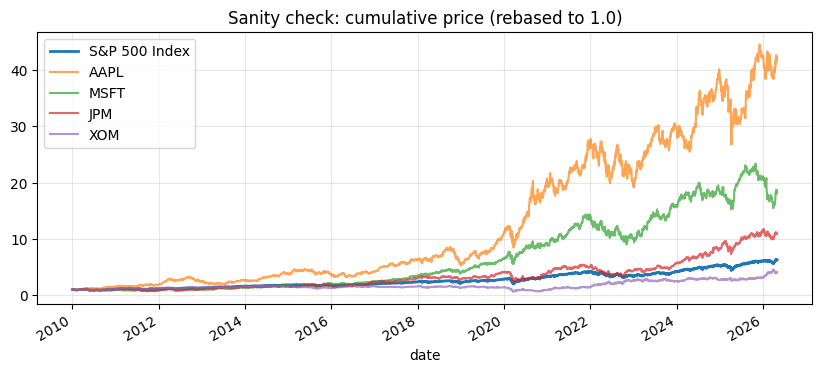

In [16]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 4))
(idx['adj_close'] / idx['adj_close'].iloc[0]).plot(ax=ax, label='S&P 500 Index', lw=2)
for t in ['AAPL', 'MSFT', 'JPM', 'XOM']:
    if t in wide_close.columns:
        (wide_close[t] / wide_close[t].dropna().iloc[0]).plot(ax=ax, label=t, alpha=0.7)
ax.set_title('Sanity check: cumulative price (rebased to 1.0)')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

In [ ]:
try:
    from google.colab import files
    files.download('sp500_index.csv')
    files.download('sp500_constituents_wide.csv')
    files.download('sp500_constituents_long.csv')
except ImportError:
    print('Not in Colab — files are saved in the working directory.')